In [1]:
# IMPORTS
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import col, max as spark_max, least, lit
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

In [2]:
# Sesión Spark
spark = SparkSession.builder \
    .appName("CMAPSS_ETL") \
    .getOrCreate()

In [3]:
# Carga del fichero raw
raw_path = "/opt/spark-data/raw/train_FD001.txt"

df = spark.read \
    .option("sep", " ") \
    .option("inferSchema", "true") \
    .csv(raw_path)

In [4]:
# EDA inicial
print("Numero de filas:",df.count())
print("Numero de columnas:", len(df.columns))
df.show()
df.printSchema()

Numero de filas: 20631
Numero de columnas: 28
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+----+----+
|_c0|_c1|    _c2|    _c3|  _c4|   _c5|   _c6|    _c7|    _c8|  _c9| _c10|  _c11|   _c12|   _c13|_c14| _c15|  _c16|   _c17|   _c18|  _c19|_c20|_c21|_c22| _c23| _c24|   _c25|_c26|_c27|
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+----+----+
|  1|  1|-7.0E-4|-4.0E-4|100.0|518.67|641.82| 1589.7| 1400.6|14.62|21.61|554.36|2388.06|9046.19| 1.3|47.47|521.66|2388.02|8138.62|8.4195|0.03| 392|2388|100.0|39.06| 23.419|NULL|NULL|
|  1|  2| 0.0019|-3.0E-4|100.0|518.67|642.15|1591.82|1403.14|14.62|21.61|553.75|2388.04|9044.07| 1.3|47.49|522.28|2388.07|8131.49|8.4318|0.03| 392|2388|100.0| 39.0|23.4236|NULL|NULL|
|  1|  3|-0.0043| 3.0E-4|100.0|518.67|6

**Vemos que algunas columnas podrían ser nulas, así que eliminamos las que lo sean.**

In [5]:
# Eliminamos columnas vacías
expr_notnull = [
    F.max(
        F.when(
            (F.col(c).isNotNull()) & (F.trim(F.col(c)) != ""),
            1
        ).otherwise(0)
    ).alias(c)
    for c in df.columns
]

resultado = df.select(expr_notnull).collect()[0].asDict()

columnas_validas = [c for c, v in resultado.items() if v == 1]

df_clean = df.select(columnas_validas)

print("Numero de columnas después de limpieza de nulos:", len(df_clean.columns))
df_clean.show()

Numero de columnas después de limpieza de nulos: 26
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+
|_c0|_c1|    _c2|    _c3|  _c4|   _c5|   _c6|    _c7|    _c8|  _c9| _c10|  _c11|   _c12|   _c13|_c14| _c15|  _c16|   _c17|   _c18|  _c19|_c20|_c21|_c22| _c23| _c24|   _c25|
+---+---+-------+-------+-----+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+----+----+-----+-----+-------+
|  1|  1|-7.0E-4|-4.0E-4|100.0|518.67|641.82| 1589.7| 1400.6|14.62|21.61|554.36|2388.06|9046.19| 1.3|47.47|521.66|2388.02|8138.62|8.4195|0.03| 392|2388|100.0|39.06| 23.419|
|  1|  2| 0.0019|-3.0E-4|100.0|518.67|642.15|1591.82|1403.14|14.62|21.61|553.75|2388.04|9044.07| 1.3|47.49|522.28|2388.07|8131.49|8.4318|0.03| 392|2388|100.0| 39.0|23.4236|
|  1|  3|-0.0043| 3.0E-4|100.0|518.67|642.35|1587.99| 1404.2|14.62|21.61|554.26|238

**Se han eliminado _c26 y _c27**

In [6]:
# Columnas del dataset CMAPSS después de limpieza 
columnas = {
    "_c0": "unit_number",
    "_c1": "time_in_cycles",
    "_c2": "setting_1",
    "_c3": "setting_2",
    "_c4": "setting_3",
    **{f"_c{i}": f"sensor_{i-4}" for i in range(5, 26)}
}
    
# Renombramos solo las columnas útiles
for antigua, nueva in columnas.items():
    df_clean = df_clean.withColumnRenamed(antigua, nueva)

In [7]:
df_clean.show()

print("-"*300)
print("VALORES ÚNICOS POR COLUMNA")
print("-"*300)

df_unicos = df_clean.select([
    F.countDistinct(c).alias(c)
    for c in df_clean.columns
])

df_unicos.show()

+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|setting_1|setting_2|setting_3|sensor_1|sensor_2|sensor_3|sensor_4|sensor_5|sensor_6|sensor_7|sensor_8|sensor_9|sensor_10|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_16|sensor_17|sensor_18|sensor_19|sensor_20|sensor_21|
+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|          1|             1|  -7.0E-4|  -4.0E-4|    100.0|  518.67|  641.82|  1589.7|  1400.6|   14.62|   21.61|  554.36| 2388.06| 9046.19|      1.3|    47.47|   521.66|  2388.02|  8138.62|   8.4195|     0.03|      392| 

**Podemos ver que existen variables constantes, que no aportan información para Machine Learning, con lo cual vamos a eliminarlas también.**

In [8]:
fila = df_unicos.collect()[0].asDict()

for c, valor in fila.items():
    if valor == 1:
        print("Eliminando",c)
        df_clean2 = df_clean.drop(c)

Eliminando setting_3
Eliminando sensor_1
Eliminando sensor_5
Eliminando sensor_10
Eliminando sensor_16
Eliminando sensor_18
Eliminando sensor_19


In [9]:
df_clean2.show()
print("Columnas trás limpieza:",len(df_clean2.columns))

+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|setting_1|setting_2|setting_3|sensor_1|sensor_2|sensor_3|sensor_4|sensor_5|sensor_6|sensor_7|sensor_8|sensor_9|sensor_10|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_16|sensor_17|sensor_18|sensor_20|sensor_21|
+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|          1|             1|  -7.0E-4|  -4.0E-4|    100.0|  518.67|  641.82|  1589.7|  1400.6|   14.62|   21.61|  554.36| 2388.06| 9046.19|      1.3|    47.47|   521.66|  2388.02|  8138.62|   8.4195|     0.03|      392|     2388|    39.06|   23.419|


In [10]:
print("-"*300)
print("DISTRIBUCIÓN POR COLUMNA")
print("-"*300)

for c in df_clean2.columns:
    print(f"\n===== {c} =====")

    df_clean.select(
        F.count(c).alias("count"),
        F.mean(c).alias("mean"),
        F.stddev(c).alias("std"),
        F.min(c).alias("min"),
        F.max(c).alias("max")
    ).show()

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
DISTRIBUCIÓN POR COLUMNA
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

===== unit_number =====
+-----+------------------+-----------------+---+---+
|count|              mean|              std|min|max|
+-----+------------------+-----------------+---+---+
|20631|51.506567786340945|29.22763290879931|  1|100|
+-----+------------------+-----------------+---+---+


===== time_in_cycles =====
+-----+------------------+-----------------+---+---+
|

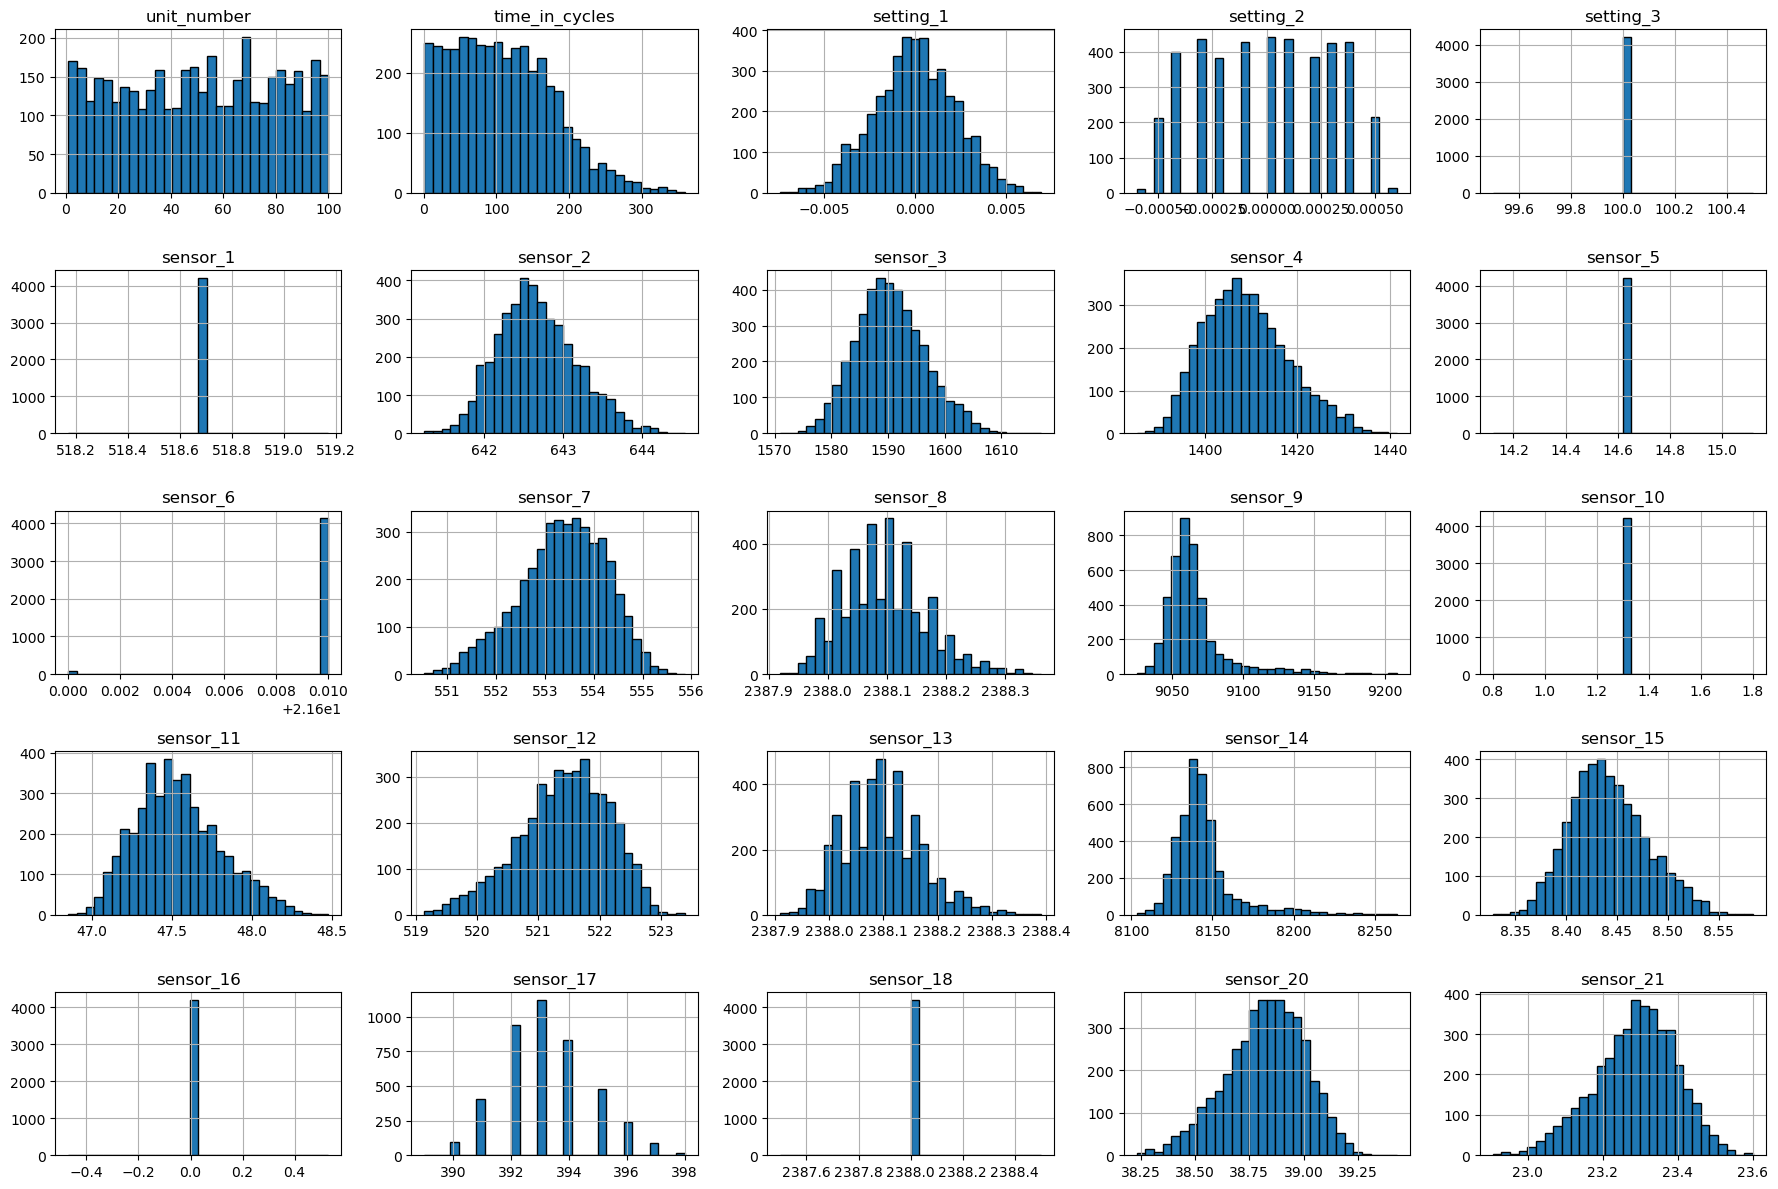

In [11]:
# HISTOGRAMAS
hdf = df_clean2.sample(False, 0.2, seed=42).toPandas()

hdf.hist(
    bins=30,
    figsize=(18, 12),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

1. **El sensor 6 tiene 2 valores que en realidad son el mismo con variación centimal. Con lo que lo eliminamos, igual que hicimos con las variables constantes.**
2. **En datasets industriales orientados a mantenimiento predictivo, los valores extremos no siempre representan ruido. Muchos corresponden a estados avanzados de degradación de la maquinaria y contienen información relevante para la predicción del fallo. Por ello, no aplicamos una eliminación agresiva de outliers.**

In [12]:
df_clean3 = df_clean2.drop("sensor_6")
df_clean3.show()

+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|unit_number|time_in_cycles|setting_1|setting_2|setting_3|sensor_1|sensor_2|sensor_3|sensor_4|sensor_5|sensor_7|sensor_8|sensor_9|sensor_10|sensor_11|sensor_12|sensor_13|sensor_14|sensor_15|sensor_16|sensor_17|sensor_18|sensor_20|sensor_21|
+-----------+--------------+---------+---------+---------+--------+--------+--------+--------+--------+--------+--------+--------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+---------+
|          1|             1|  -7.0E-4|  -4.0E-4|    100.0|  518.67|  641.82|  1589.7|  1400.6|   14.62|  554.36| 2388.06| 9046.19|      1.3|    47.47|   521.66|  2388.02|  8138.62|   8.4195|     0.03|      392|     2388|    39.06|   23.419|
|          1|             2|   0.001

In [13]:
# Cálculo del RUL
ventana_unit = Window.partitionBy("unit_number")

df_rul = df_clean3.withColumn(
    "max_cycle",
    F.max("time_cycles").over(ventana_unit)
)

# RUL = último ciclo del motor - ciclo actual

df_rul = df_rul.withColumn(
    "RUL",
    F.col("max_cycle") - F.col("time_cycles")
)

# ---------------------------------------------------------
# 5. Opcional: aplicar RUL capado
# ---------------------------------------------------------
# En mantenimiento predictivo es común limitar el RUL máximo,
# por ejemplo a 125 ciclos, para evitar que valores muy altos
# dominen el entrenamiento del modelo.

# RUL_CAP = 125

# df_rul = df_rul.withColumn(
#     "RUL_capped",
#     when(col("RUL") > RUL_CAP, RUL_CAP).otherwise(col("RUL"))
# )

# ---------------------------------------------------------
# 6. Eliminar columna auxiliar
# ---------------------------------------------------------
df_rul = df_rul.drop("max_cycle")

# ---------------------------------------------------------
# 7. Guardar dataset procesado en Parquet
# ---------------------------------------------------------
# output_path = "hdfs:///data/processed/cmapss/train_FD001_rul.parquet"

# df_rul.write \
#     .mode("overwrite") \
#     .parquet(output_path)

# # ---------------------------------------------------------
# # 8. Comprobar resultado
# # ---------------------------------------------------------
# df_rul.select(
#     "unit_number",
#     "time_cycles",
#     "RUL",
#     "RUL_capped"
# ).show(20)

df_rul.show()

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `time_cycles` cannot be resolved. Did you mean one of the following? [`time_in_cycles`, `sensor_1`, `sensor_2`, `sensor_3`, `sensor_4`].;
'Project [unit_number#629, time_in_cycles#656, setting_1#683, setting_2#710, setting_3#737, sensor_1#764, sensor_2#791, sensor_3#818, sensor_4#845, sensor_5#872, sensor_7#926, sensor_8#953, sensor_9#980, sensor_10#1007, sensor_11#1034, sensor_12#1061, sensor_13#1088, sensor_14#1115, sensor_15#1142, sensor_16#1169, sensor_17#1196, sensor_18#1223, sensor_20#1277, sensor_21#1304, max('time_cycles) windowspecdefinition(unit_number#629, unspecifiedframe$()) AS max_cycle#5172]
+- Project [unit_number#629, time_in_cycles#656, setting_1#683, setting_2#710, setting_3#737, sensor_1#764, sensor_2#791, sensor_3#818, sensor_4#845, sensor_5#872, sensor_7#926, sensor_8#953, sensor_9#980, sensor_10#1007, sensor_11#1034, sensor_12#1061, sensor_13#1088, sensor_14#1115, sens